<a href="https://colab.research.google.com/github/VardhanVelamakanni/EEG_GAF/blob/main/EEG_GAF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pyEDFlib pyts tqdm matplotlib scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 91.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 94.5 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import requests
from tqdm import tqdm

base_url = "https://physionet.org/files/chbmit/1.0.0/"
patients = ["chb01","chb02","chb03","chb04","chb05","chb06","chb08","chb09","chb10","chb11","chb14","chb17","chb18"]

save_dir = "/content/drive/MyDrive/chbmit_subset"
os.makedirs(save_dir, exist_ok=True)

def download_file(url, filename):
    response = requests.get(url, stream=True)
    total = int(response.headers.get('content-length', 0))
    with open(filename, 'wb') as file, tqdm(total=total, unit='B', unit_scale=True) as bar:
        for data in response.iter_content(1024):
            size = file.write(data)
            bar.update(size)

for patient in patients:
    patient_url = base_url + patient + "/"
    patient_dir = os.path.join(save_dir, patient)
    os.makedirs(patient_dir, exist_ok=True)

    html = requests.get(patient_url).text
    count = 0

    for line in html.split("\n"):
        if ".edf" in line:
            if count >= 8:   # LIMIT → keeps it lightweight
                break
            filename = line.split('"')[1]
            file_url = patient_url + filename
            save_path = os.path.join(patient_dir, filename)

            if not os.path.exists(save_path):
                download_file(file_url, save_path)
                count += 1

100%|██████████| 42.4M/42.4M [03:51<00:00, 183kB/s]
100%|██████████| 42.4M/42.4M [03:19<00:00, 212kB/s]
100%|██████████| 42.4M/42.4M [03:31<00:00, 201kB/s]
100%|██████████| 54.0/54.0 [00:00<00:00, 314kB/s]
100%|██████████| 42.4M/42.4M [03:32<00:00, 199kB/s]
100%|██████████| 54.0/54.0 [00:00<00:00, 245kB/s]
100%|██████████| 42.4M/42.4M [03:29<00:00, 202kB/s]
100%|██████████| 42.4M/42.4M [03:26<00:00, 205kB/s]
100%|██████████| 42.4M/42.4M [03:46<00:00, 187kB/s]
100%|██████████| 42.4M/42.4M [03:41<00:00, 192kB/s]
100%|██████████| 42.4M/42.4M [03:58<00:00, 178kB/s]
100%|██████████| 42.4M/42.4M [03:58<00:00, 178kB/s]
100%|██████████| 42.4M/42.4M [04:15<00:00, 166kB/s]
100%|██████████| 42.4M/42.4M [04:17<00:00, 165kB/s]
100%|██████████| 42.4M/42.4M [04:14<00:00, 166kB/s]
100%|██████████| 42.4M/42.4M [04:10<00:00, 169kB/s]
100%|██████████| 42.4M/42.4M [03:48<00:00, 185kB/s]
100%|██████████| 54.0/54.0 [00:00<00:00, 241kB/s]
100%|██████████| 42.4M/42.4M [04:03<00:00, 174kB/s]
100%|██████████| 5

In [ ]:
import pyedflib
import numpy as np

def load_edf(file_path):
    f = pyedflib.EdfReader(file_path)
    n = f.signals_in_file
    signals = np.array([f.readSignal(i) for i in range(min(3, n))])  # only 3 channels
    f.close()
    return signals

def segment_signal(signal, window_size=512, step=256):
    segments = []
    for i in range(0, signal.shape[1] - window_size, step):
        segments.append(signal[:, i:i+window_size])
    return np.array(segments)

In [ ]:
from pyts.image import GramianAngularField

gaf = GramianAngularField(method='summation')

def signal_to_gaf(segment):
    images = []
    for ch in segment:
        ch = (ch - ch.min()) / (ch.max() - ch.min() + 1e-6)
        img = gaf.fit_transform(ch.reshape(1, -1))[0]
        images.append(img)
    return np.stack(images, axis=-1)  # RGB

In [ ]:
import os

base_out = "/content/gaf_dataset"
os.makedirs(base_out, exist_ok=True)

os.makedirs(f"{base_out}/seizure", exist_ok=True)
os.makedirs(f"{base_out}/normal", exist_ok=True)

In [ ]:
import cv2

count = 0

for patient in os.listdir(data_dir):
    patient_path = os.path.join(data_dir, patient)

    for file in os.listdir(patient_path):
        if file.endswith(".edf"):
            path = os.path.join(patient_path, file)

            try:
                signal = load_edf(path)
            except:
                print(f"Skipping {file}")
                continue

            segments = segment_signal(signal)

            for i, seg in enumerate(segments[:20]):

                try:
                    img = signal_to_gaf(seg)

                    # Normalize to 0–255
                    img = (img * 255).astype("uint8")

                    # Resize (IMPORTANT for ResNet)
                    img = cv2.resize(img, (224, 224))

                    # TEMP: all normal (we fix later)
                    label = "normal"

                    filename = f"{base_out}/{label}/{patient}_{file}_{i}.png"
                    cv2.imwrite(filename, img)

                    count += 1

                except:
                    continue

print("Saved images:", count)

In [ ]:
!zip -r gaf_dataset.zip /content/gaf_dataset

  adding: content/gaf_dataset/ (stored 0%)
  adding: content/gaf_dataset/seizure/ (stored 0%)
  adding: content/gaf_dataset/normal/ (stored 0%)
  adding: content/gaf_dataset/normal/chb08_chb08_03.edf_6.png (deflated 0%)
  adding: content/gaf_dataset/normal/chb05_chb05_03.edf_7.png (deflated 0%)
  adding: content/gaf_dataset/normal/chb02_chb02_04.edf_13.png (deflated 0%)
  adding: content/gaf_dataset/normal/chb01_chb01_01.edf_1.png (deflated 0%)
  adding: content/gaf_dataset/normal/chb09_chb09_01.edf_2.png (deflated 0%)
  adding: content/gaf_dataset/normal/chb06_chb06_06.edf_4.png (deflated 0%)
  adding: content/gaf_dataset/normal/chb06_chb06_01.edf_19.png (deflated 0%)
  adding: content/gaf_dataset/normal/chb01_chb01_05.edf_19.png (deflated 0%)
  adding: content/gaf_dataset/normal/chb09_chb09_04.edf_19.png (deflated 0%)
  adding: content/gaf_dataset/normal/chb05_chb05_06.edf_19.png (deflated 0%)
  adding: content/gaf_dataset/normal/chb06_chb06_03.edf_4.png (deflated 0%)
  adding: conte

In [ ]:
from google.colab import files
files.download("gaf_dataset.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import matplotlib.pyplot as plt

X = []
y = []

data_dir = "/content/chbmit_subset"

for patient in os.listdir(data_dir):
    patient_path = os.path.join(data_dir, patient)

    for file in os.listdir(patient_path):
        if file.endswith(".edf"):
            path = os.path.join(patient_path, file)

            try:
                signal = load_edf(path)
            except Exception as e:
                print(f" Skipping corrupted file: {file}")
                continue   # skip bad file safely

            segments = segment_signal(signal)

            for seg in segments[:20]:  # LIMIT → fast
                try:
                    img = signal_to_gaf(seg)
                    X.append(img)
                    y.append(0)  # placeholder label
                except:
                    continue  # skip bad segment if any

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

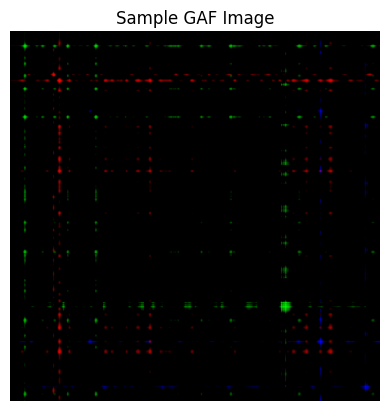

In [ ]:
plt.imshow(X[0])
plt.title("Sample GAF Image")
plt.axis("off")

In [ ]:
import numpy as np

X = np.array(X)
y = np.array(y)

np.save("/content/X.npy", X)
np.save("/content/y.npy", y)

In [ ]:
import numpy as np

X = np.array(X)
y = np.array(y)

np.save("/content/X.npy", X)
np.save("/content/y.npy", y)

In [ ]:
!zip -r chbmit_subset.zip /content/chbmit_subset

  adding: content/chbmit_subset/ (stored 0%)
  adding: content/chbmit_subset/chb09/ (stored 0%)
  adding: content/chbmit_subset/chb09/chb09_03.edf (deflated 38%)
  adding: content/chbmit_subset/chb09/chb09_01.edf (deflated 37%)
  adding: content/chbmit_subset/chb09/chb09_07.edf (deflated 38%)
  adding: content/chbmit_subset/chb09/chb09_06.edf.seizures (deflated 2%)
  adding: content/chbmit_subset/chb09/chb09_05.edf (deflated 26%)
  adding: content/chbmit_subset/chb09/chb09_02.edf (deflated 36%)
  adding: content/chbmit_subset/chb09/chb09_04.edf (deflated 41%)
  adding: content/chbmit_subset/chb09/chb09_06.edf (deflated 33%)
  adding: content/chbmit_subset/chb03/ (stored 0%)
  adding: content/chbmit_subset/chb03/chb03_03.edf.seizures (deflated 4%)
  adding: content/chbmit_subset/chb03/chb03_04.edf (deflated 45%)
  adding: content/chbmit_subset/chb03/chb03_02.edf.seizures (deflated 2%)
  adding: content/chbmit_subset/chb03/chb03_01.edf (deflated 44%)
  adding: content/chbmit_subset/chb03

In [ ]:
from google.colab import files
files.download("chbmit_subset.zip")j

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>